In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (운영체제별)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (Colab 등)
    # 나눔고딕 설치
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# LogisticRegression

Recall  : 0.7647
ROC-AUC : 0.8271
F1-score: 0.1675


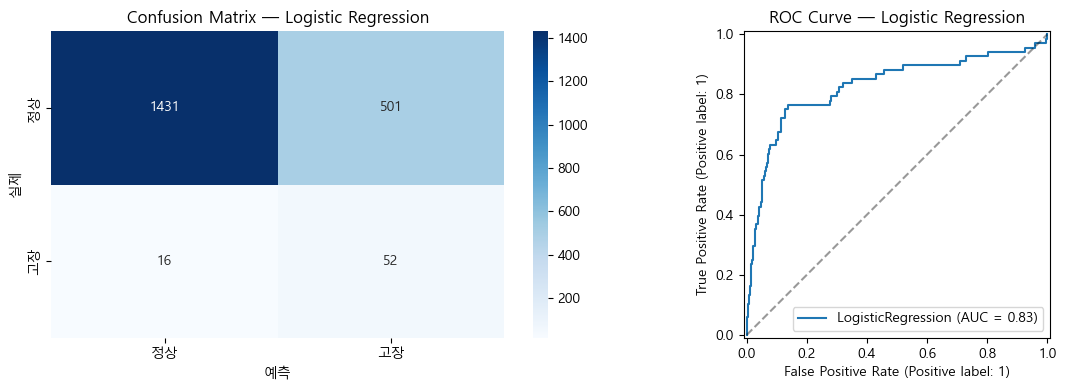

In [2]:
# ── 0. 라이브러리 ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, recall_score, RocCurveDisplay
)

# ── 1. 데이터 로드 & 파생변수 ─────────────────────────────────
df = pd.read_csv('ai4i2020.csv')
df.columns = df.columns.str.strip()

df['Temp_diff']    = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']        = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['Torque_Wear']  = df['Torque [Nm]'] * df['Tool wear [min]']
df['Type_encoded'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# ── 2. 피처 / 타겟 분리 ───────────────────────────────────────
FEATURES = ['Type_encoded', 'Temp_diff', 'Power', 'Torque_Wear']
TARGET   = 'Machine failure'

X = df[FEATURES]
y = df[TARGET]

# ── 3. Train/Test 분할 ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. 스케일링 ───────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 5. 모델 학습 ──────────────────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# ── 6. 예측 ──────────────────────────────────────────────────
y_pred  = lr.predict(X_test_sc)
y_proba = lr.predict_proba(X_test_sc)[:, 1]

# ── 7. 평가지표 출력 ──────────────────────────────────────────
print(f'Recall  : {recall_score(y_test, y_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred):.4f}')

# ── 8. 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix — Logistic Regression')

# ROC 커브
RocCurveDisplay.from_estimator(lr, X_test_sc, y_test, ax=axes[1])
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

class_weight='balanced'가 고장을 잡으려다 보니 정상을 고장으로 너무 많이 예측하고 있음. 501건 오탐은 좀 많은 편이에요. 그래서 F1이 0.16으로 낮게 나온 거임.

Logistic Regression 자체 한계
이 데이터는 고장 메커니즘이 비선형적임. 예를 들어 Power가 특정 구간을 벗어날 때만 고장이 나는 구조인데, LR은 선형 경계만 그을 수 있어서 이런 패턴을 잡기 어려움.

-------------------------------------------------------------------------
Type_encoded    # 제품 등급
Temp_diff       # 파생 (HDF)
Power           # 파생 (PWF)
Torque_Wear     # 파생 (OSF)
Tool wear [min] # 원본 추가


# Random Forest

Recall  : 0.4412
ROC-AUC : 0.9410
F1-score: 0.5941


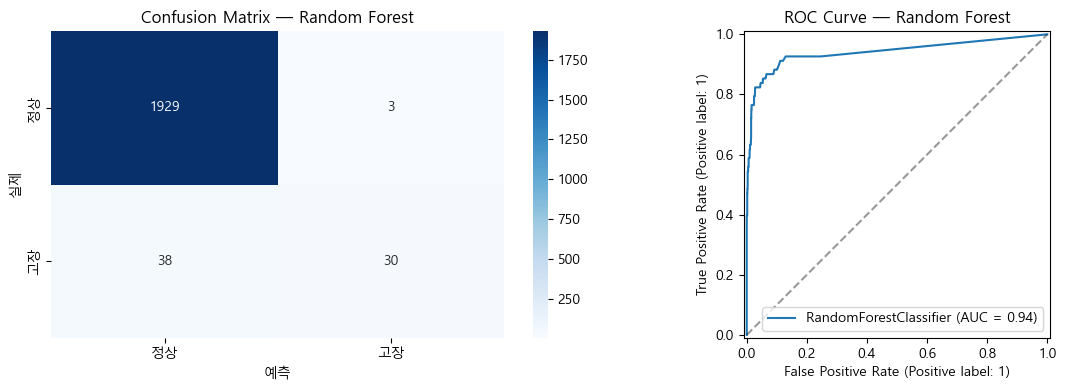

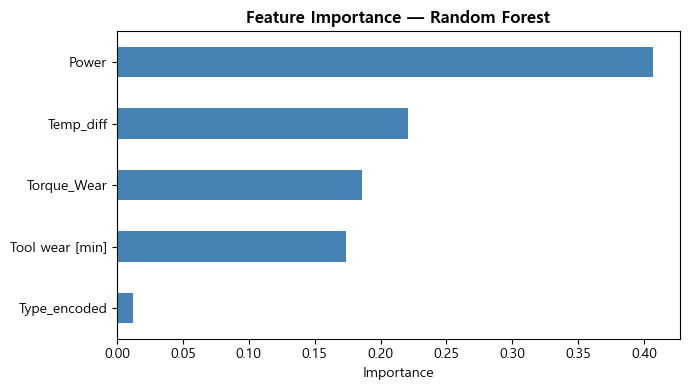

In [3]:
# ── 1. 피처 / 타겟 분리 ───────────────────────────────────────
# (데이터 로드 & 파생변수는 위 코드 그대로 재사용)

FEATURES_RF = ['Type_encoded', 'Temp_diff', 'Power', 'Torque_Wear', 'Tool wear [min]']
TARGET      = 'Machine failure'

X_rf = df[FEATURES_RF]
y    = df[TARGET]

# ── 2. Train/Test 분할 ────────────────────────────────────────
X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)
# 트리 모델은 스케일링 불필요 → 원본 그대로 사용

# ── 3. 모델 학습 ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train)

# ── 4. 예측 ──────────────────────────────────────────────────
y_pred_rf  = rf.predict(X_test_rf)
y_proba_rf = rf.predict_proba(X_test_rf)[:, 1]

# ── 5. 평가지표 출력 ──────────────────────────────────────────
from sklearn.metrics import recall_score, roc_auc_score, f1_score

print(f'Recall  : {recall_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_rf):.4f}')

# ── 6. 시각화 ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix — Random Forest')

# ROC 커브
RocCurveDisplay.from_estimator(rf, X_test_rf, y_test, ax=axes[1])
axes[1].set_title('ROC Curve — Random Forest')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 7. 피처 중요도 ────────────────────────────────────────────
importance = pd.Series(rf.feature_importances_, index=FEATURES_RF).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

RF가 LR보다 전반적으로 좋아졌는데 Recall만 오히려 떨어짐. 이유는 LR은 오탐을 501건이나 내면서 고장을 많이 잡은 반면, 
RF는 오탐을 3건으로 줄이는 대신 고장을 더 많이 놓치는 방향으로 학습된 거임.
쉽게 말하면

* LR → 의심되면 일단 다 고장이라고 외침 → Recall 높음
* RF → 확실한 것만 고장이라고 함 → Precision 높음

피처 중요도도 의미있음
Power가 압도적 1위(0.40)인데, EDA에서 PWF 탐지 핵심이라고 했던 게 모델에서도 그대로 증명됨. 
Type_encoded는 거의 영향이 없음.

## 핵심과제는 Recall을 올리는 것 

* threshold 조정해보기!!


 Threshold  Recall  ROC-AUC  F1-score
      0.10  0.8235    0.941    0.5437
      0.15  0.7941    0.941    0.6316
      0.20  0.7500    0.941    0.6846
      0.25  0.6176    0.941    0.6412
      0.30  0.5735    0.941    0.6555
      0.35  0.5441    0.941    0.6549
      0.40  0.5147    0.941    0.6422
      0.45  0.4853    0.941    0.6286
      0.50  0.4412    0.941    0.5941
      0.55  0.4118    0.941    0.5657


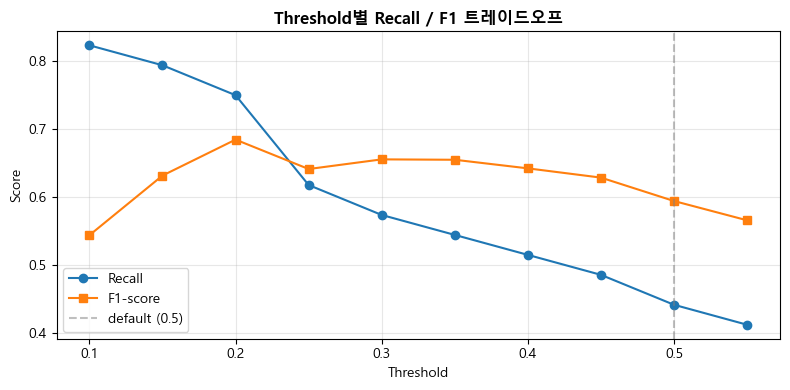

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, roc_auc_score, f1_score, confusion_matrix
import seaborn as sns

# ── 1. 다양한 threshold별 지표 확인 ──────────────────────────
thresholds = np.arange(0.1, 0.6, 0.05)

results = []
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    results.append({
        'Threshold' : round(t, 2),
        'Recall'    : recall_score(y_test, y_pred_t),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_rf),
        'F1-score'  : f1_score(y_test, y_pred_t),
    })

result_df = pd.DataFrame(results)
print(result_df.round(4).to_string(index=False))

# ── 2. Recall / F1 트레이드오프 시각화 ───────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(result_df['Threshold'], result_df['Recall'], marker='o', label='Recall')
ax.plot(result_df['Threshold'], result_df['F1-score'], marker='s', label='F1-score')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold별 Recall / F1 트레이드오프', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

피처      : Type_encoded, Temp_diff, Power, Torque_Wear, Tool wear [min]
Threshold : 0.20
Recall    : 0.7500
F1-score  : 0.6846
ROC-AUC   : 0.9410

지금 threshold 0.20은 test 데이터를 보고 고른 거임 이게 새로운 데이터에서도 최적일 보장은 없음.


-----
* train 데이터로만 threshold 탐색
*        ↓
* test 데이터에 적용해서 최종 확인 


# XGBoost

scale_pos_weight: 28.52
Recall  : 0.8971
ROC-AUC : 0.9700
F1-score: 0.3961


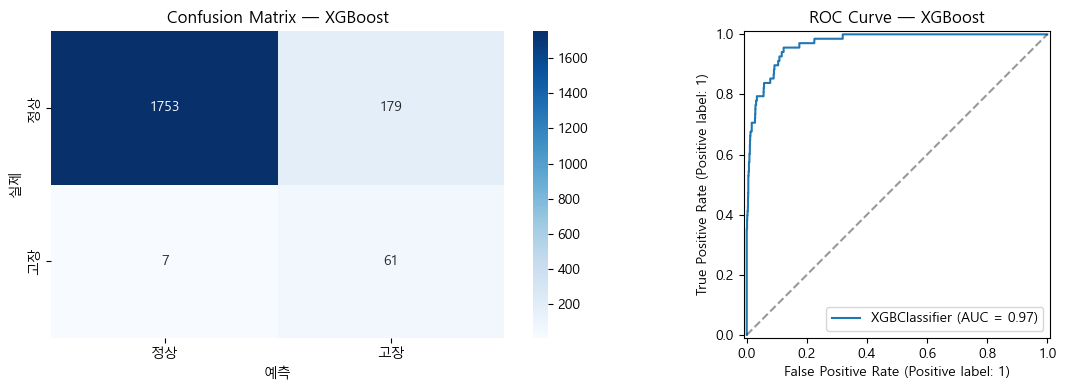

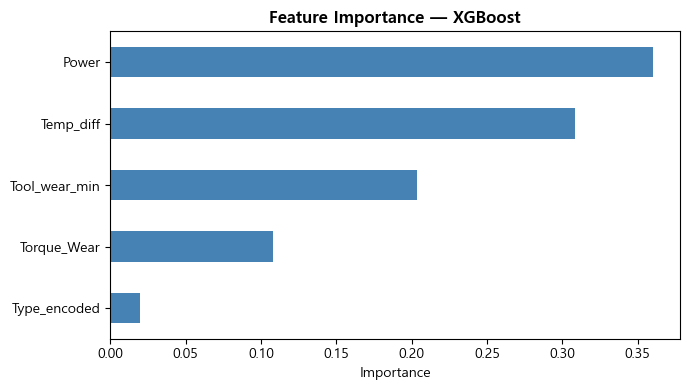

In [5]:
from xgboost import XGBClassifier

# 컬럼명에서 괄호 제거
df = df.rename(columns={'Tool wear [min]': 'Tool_wear_min'})

FEATURES_RF = ['Type_encoded', 'Temp_diff', 'Power', 'Torque_Wear', 'Tool_wear_min']

X_rf = df[FEATURES_RF]
y    = df[TARGET]

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)




# ── 1. scale_pos_weight 계산 (class_weight='balanced' 대신) ──
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f'scale_pos_weight: {scale_pos:.2f}')

# ── 2. 모델 학습 ──────────────────────────────────────────────
xgb = XGBClassifier(
    scale_pos_weight=scale_pos,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_rf, y_train)  # RF랑 동일한 피처 사용

# ── 3. 예측 ──────────────────────────────────────────────────
y_proba_xgb = xgb.predict_proba(X_test_rf)[:, 1]
y_pred_xgb  = (y_proba_xgb >= 0.20).astype(int)  # threshold 0.20 적용

# ── 4. 평가지표 출력 ──────────────────────────────────────────
print(f'Recall  : {recall_score(y_test, y_pred_xgb):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_xgb):.4f}')

# ── 5. 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix — XGBoost')

# ROC 커브
RocCurveDisplay.from_estimator(xgb, X_test_rf, y_test, ax=axes[1])
axes[1].set_title('ROC Curve — XGBoost')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 6. 피처 중요도 ────────────────────────────────────────────
importance = pd.Series(
    xgb.feature_importances_, index=FEATURES_RF
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — XGBoost', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

 Threshold  Recall  ROC-AUC  F1-score
      0.10  0.9265     0.97    0.3642
      0.15  0.8971     0.97    0.3720
      0.20  0.8971     0.97    0.3961
      0.25  0.8529     0.97    0.4042
      0.30  0.8382     0.97    0.4222
      0.35  0.8382     0.97    0.4402
      0.40  0.8382     0.97    0.4542
      0.45  0.8382     0.97    0.4770
      0.50  0.7941     0.97    0.4779
      0.55  0.7941     0.97    0.5070


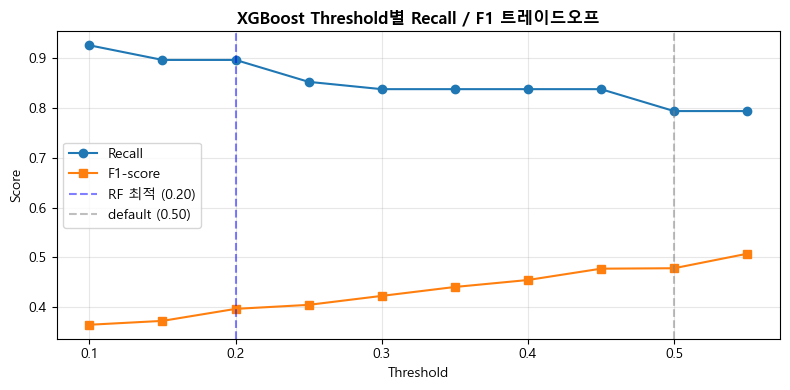

In [6]:
# ── XGBoost threshold 탐색 ────────────────────────────────────
thresholds = np.arange(0.1, 0.6, 0.05)

results_xgb = []
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    results_xgb.append({
        'Threshold' : round(t, 2),
        'Recall'    : recall_score(y_test, y_pred_t),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_xgb),
        'F1-score'  : f1_score(y_test, y_pred_t),
    })

result_xgb_df = pd.DataFrame(results_xgb)
print(result_xgb_df.round(4).to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(result_xgb_df['Threshold'], result_xgb_df['Recall'], marker='o', label='Recall')
ax.plot(result_xgb_df['Threshold'], result_xgb_df['F1-score'], marker='s', label='F1-score')
ax.axvline(x=0.20, color='blue', linestyle='--', alpha=0.5, label='RF 최적 (0.20)')
ax.axvline(x=0.50, color='gray', linestyle='--', alpha=0.5, label='default (0.50)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost Threshold별 Recall / F1 트레이드오프', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 Threshold  Recall  ROC-AUC  F1-score
      0.10  0.9265     0.97    0.3642
      0.15  0.8971     0.97    0.3720
      0.20  0.8971     0.97    0.3961
      0.25  0.8529     0.97    0.4042
      0.30  0.8382     0.97    0.4222
      0.35  0.8382     0.97    0.4402
      0.40  0.8382     0.97    0.4542
      0.45  0.8382     0.97    0.4770
      0.50  0.7941     0.97    0.4779
      0.55  0.7941     0.97    0.5070
      0.60  0.7941     0.97    0.5455
      0.65  0.7794     0.97    0.5761
      0.70  0.7500     0.97    0.5829
      0.75  0.7059     0.97    0.5890
      0.80  0.7059     0.97    0.6316
      0.85  0.6765     0.97    0.6301


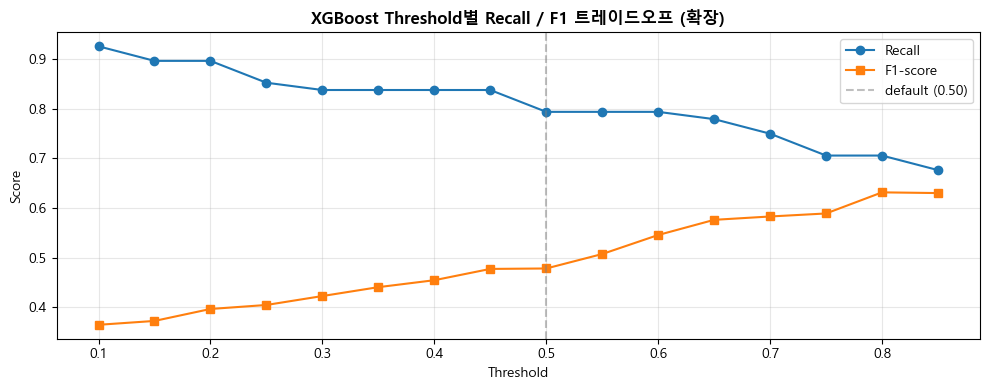

In [7]:
thresholds = np.arange(0.1, 0.9, 0.05)

results_xgb2 = []
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    results_xgb2.append({
        'Threshold' : round(t, 2),
        'Recall'    : recall_score(y_test, y_pred_t),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_xgb),
        'F1-score'  : f1_score(y_test, y_pred_t),
    })

result_xgb_df2 = pd.DataFrame(results_xgb2)
print(result_xgb_df2.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result_xgb_df2['Threshold'], result_xgb_df2['Recall'], marker='o', label='Recall')
ax.plot(result_xgb_df2['Threshold'], result_xgb_df2['F1-score'], marker='s', label='F1-score')
ax.axvline(x=0.50, color='gray', linestyle='--', alpha=0.5, label='default (0.50)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost Threshold별 Recall / F1 트레이드오프 (확장)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Threshold 0.35로 확정 (Recall을 우선으로 함)

# LightGBM

Recall  : 0.8088
ROC-AUC : 0.9680
F1-score: 0.5164


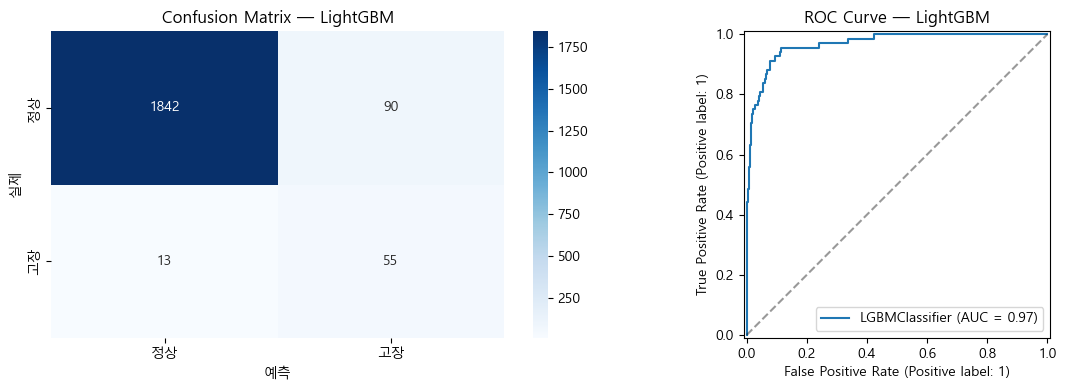

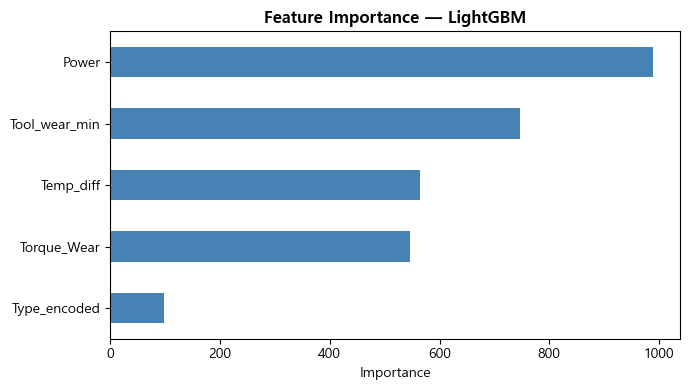

In [8]:
from lightgbm import LGBMClassifier

# ── 1. 모델 학습 ──────────────────────────────────────────────
lgbm = LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train_rf, y_train)  # XGBoost랑 동일한 피처 사용

# ── 2. 예측 (일단 default threshold 0.5로 확인) ───────────────
y_proba_lgbm = lgbm.predict_proba(X_test_rf)[:, 1]
y_pred_lgbm  = (y_proba_lgbm >= 0.5).astype(int)

# ── 3. 평가지표 출력 ──────────────────────────────────────────
print(f'Recall  : {recall_score(y_test, y_pred_lgbm):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_lgbm):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_lgbm):.4f}')

# ── 4. 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix — LightGBM')

# ROC 커브
RocCurveDisplay.from_estimator(lgbm, X_test_rf, y_test, ax=axes[1])
axes[1].set_title('ROC Curve — LightGBM')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 5. 피처 중요도 ────────────────────────────────────────────
importance = pd.Series(
    lgbm.feature_importances_, index=FEATURES_RF
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — LightGBM', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

 Threshold  Recall  ROC-AUC  F1-score
      0.10  0.9265    0.968    0.3807
      0.15  0.9118    0.968    0.4079
      0.20  0.9118    0.968    0.4189
      0.25  0.8971    0.968    0.4373
      0.30  0.8824    0.968    0.4598
      0.35  0.8676    0.968    0.4664
      0.40  0.8382    0.968    0.4851
      0.45  0.8088    0.968    0.4911
      0.50  0.8088    0.968    0.5164
      0.55  0.7941    0.968    0.5347
      0.60  0.7647    0.968    0.5417
      0.65  0.7647    0.968    0.5778
      0.70  0.7647    0.968    0.6047
      0.75  0.7500    0.968    0.6182
      0.80  0.7353    0.968    0.6494
      0.85  0.6912    0.968    0.6573


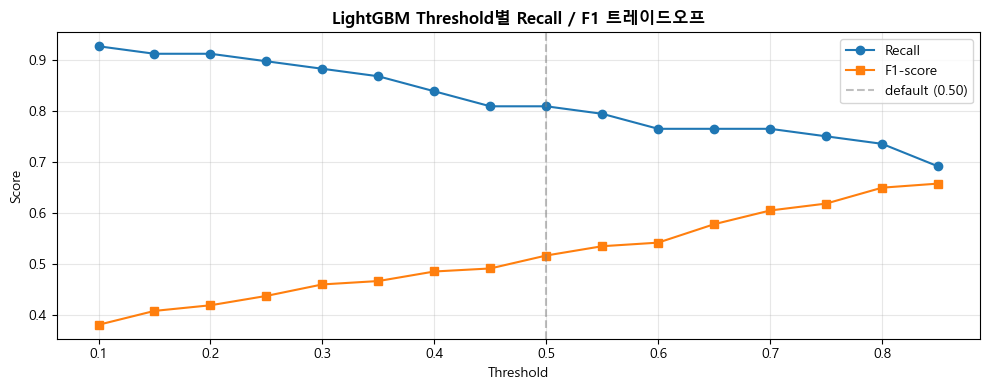

In [9]:
# ── LightGBM threshold 탐색 ───────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.05)

results_lgbm = []
for t in thresholds:
    y_pred_t = (y_proba_lgbm >= t).astype(int)
    results_lgbm.append({
        'Threshold' : round(t, 2),
        'Recall'    : recall_score(y_test, y_pred_t),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_lgbm),
        'F1-score'  : f1_score(y_test, y_pred_t),
    })

result_lgbm_df = pd.DataFrame(results_lgbm)
print(result_lgbm_df.round(4).to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result_lgbm_df['Threshold'], result_lgbm_df['Recall'], marker='o', label='Recall')
ax.plot(result_lgbm_df['Threshold'], result_lgbm_df['F1-score'], marker='s', label='F1-score')
ax.axvline(x=0.50, color='gray', linestyle='--', alpha=0.5, label='default (0.50)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('LightGBM Threshold별 Recall / F1 트레이드오프', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 모델 선정 LightGBM. 
* 균형 최고 → LightGBM (Recall 0.81, F1 0.52) Recall과 F1을 동시에 고려하면 LightGBM이 가장 균형잡힌 모델임.
### 하이퍼파라미터 튜닝하기
*  Random Search로 넓게 탐색한 다음 좋은 범위를 좁혀서 Grid Search로 정밀하게 찾는 방식

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ── 1. 탐색 범위 설정 (넓게) ──────────────────────────────────
param_dist = {
    'n_estimators'  : randint(100, 600),      # 100 ~ 600
    'learning_rate' : uniform(0.01, 0.19),    # 0.01 ~ 0.20
    'max_depth'     : randint(3, 9),          # 3 ~ 8
    'num_leaves'    : randint(20, 100),       # 20 ~ 100
    'min_child_samples': randint(5, 50),      # 과적합 방지
}

# ── 2. Random Search ──────────────────────────────────────────
lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

random_search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_dist,
    n_iter=50,              # 50가지 조합 랜덤 시도
    scoring='recall',       # Recall 기준으로 최적화
    cv=5,                   # 5-Fold CV
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_rf, y_train)

print(f'\n최적 파라미터:')
print(random_search.best_params_)
print(f'\nBest CV Recall: {random_search.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

최적 파라미터:
{'learning_rate': np.float64(0.04512234654985014), 'max_depth': 4, 'min_child_samples': 30, 'n_estimators': 143, 'num_leaves': 53}

Best CV Recall: 0.9077


* learning_rate  : 0.045  → 0.01 ~ 0.20 범위에서 낮은 쪽
* max_depth      : 4      → 3 ~ 8 범위에서 낮은 쪽
* min_child_samples: 30   → 5 ~ 50 범위에서 중간
* n_estimators   : 143    → 100 ~ 600 범위에서 낮은 쪽
* num_leaves     : 53     → 20 ~ 100 범위에서 중간

In [11]:
from sklearn.model_selection import GridSearchCV

# ── Random Search 결과 기반으로 범위 좁힘 ─────────────────────
param_grid = {
    'n_estimators'     : [100, 143, 180, 220],   # 143 주변
    'learning_rate'    : [0.03, 0.045, 0.06],    # 0.045 주변
    'max_depth'        : [3, 4, 5],              # 4 주변
    'num_leaves'       : [40, 53, 65],           # 53 주변
    'min_child_samples': [20, 30, 40],           # 30 주변
}

# 총 조합: 4×3×3×3×3 = 324가지
print(f'총 조합 수: {4*3*3*3*3}가지')

# ── Grid Search ───────────────────────────────────────────────
lgbm_base2 = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

grid_search = GridSearchCV(
    lgbm_base2,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_rf, y_train)

print(f'\n최적 파라미터:')
print(grid_search.best_params_)
print(f'Best CV Recall: {grid_search.best_score_:.4f}')

총 조합 수: 324가지
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

최적 파라미터:
{'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 30, 'n_estimators': 143, 'num_leaves': 40}
Best CV Recall: 0.9630


Recall  : 0.9412
ROC-AUC : 0.9585
F1-score: 0.4197


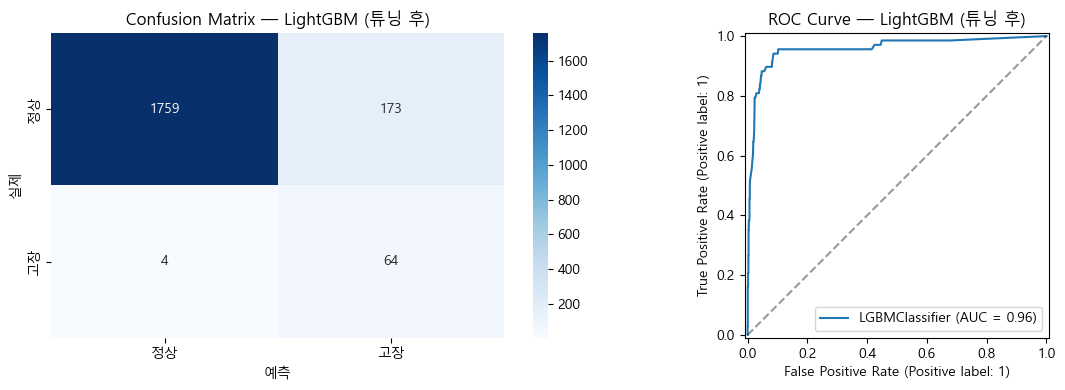

In [12]:
# ── 튜닝된 모델로 최종 평가 ───────────────────────────────────
best_lgbm = grid_search.best_estimator_

y_proba_best = best_lgbm.predict_proba(X_test_rf)[:, 1]
y_pred_best  = (y_proba_best >= 0.5).astype(int)

print(f'Recall  : {recall_score(y_test, y_pred_best):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_best):.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix — LightGBM (튜닝 후)')

RocCurveDisplay.from_estimator(best_lgbm, X_test_rf, y_test, ax=axes[1])
axes[1].set_title('ROC Curve — LightGBM (튜닝 후)')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

 Threshold  Recall  ROC-AUC  F1-score
      0.10  0.9559   0.9585    0.1923
      0.15  0.9559   0.9585    0.2544
      0.20  0.9559   0.9585    0.3140
      0.25  0.9559   0.9585    0.3308
      0.30  0.9559   0.9585    0.3377
      0.35  0.9559   0.9585    0.3385
      0.40  0.9559   0.9585    0.3927
      0.45  0.9412   0.9585    0.4156
      0.50  0.9412   0.9585    0.4197
      0.55  0.8971   0.9585    0.4266
      0.60  0.8971   0.9585    0.4485
      0.65  0.8676   0.9585    0.5514
      0.70  0.8088   0.9585    0.6111
      0.75  0.7941   0.9585    0.6429
      0.80  0.7941   0.9585    0.6467
      0.85  0.6471   0.9585    0.5867


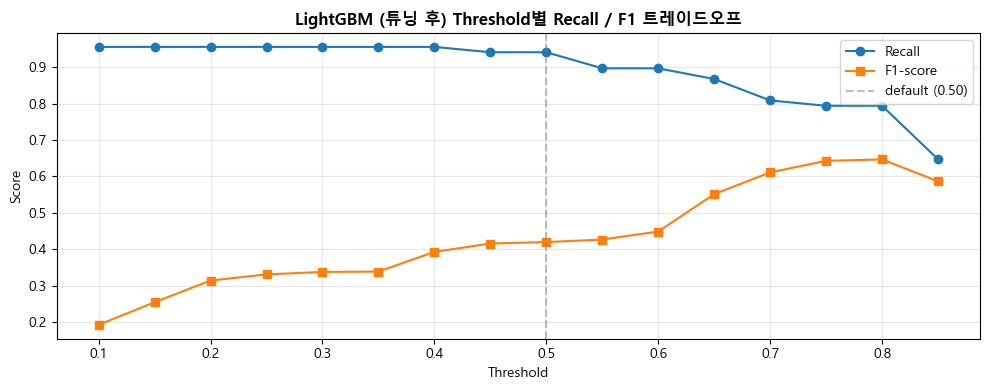

In [13]:
# ── 튜닝된 LightGBM threshold 탐색 ───────────────────────────
thresholds = np.arange(0.1, 0.9, 0.05)

results_best = []
for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    results_best.append({
        'Threshold' : round(t, 2),
        'Recall'    : recall_score(y_test, y_pred_t),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_best),
        'F1-score'  : f1_score(y_test, y_pred_t),
    })

result_best_df = pd.DataFrame(results_best)
print(result_best_df.round(4).to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result_best_df['Threshold'], result_best_df['Recall'], marker='o', label='Recall')
ax.plot(result_best_df['Threshold'], result_best_df['F1-score'], marker='s', label='F1-score')
ax.axvline(x=0.50, color='gray', linestyle='--', alpha=0.5, label='default (0.50)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('LightGBM (튜닝 후) Threshold별 Recall / F1 트레이드오프', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Recall  : 0.8088
ROC-AUC : 0.9585
F1-score: 0.6111


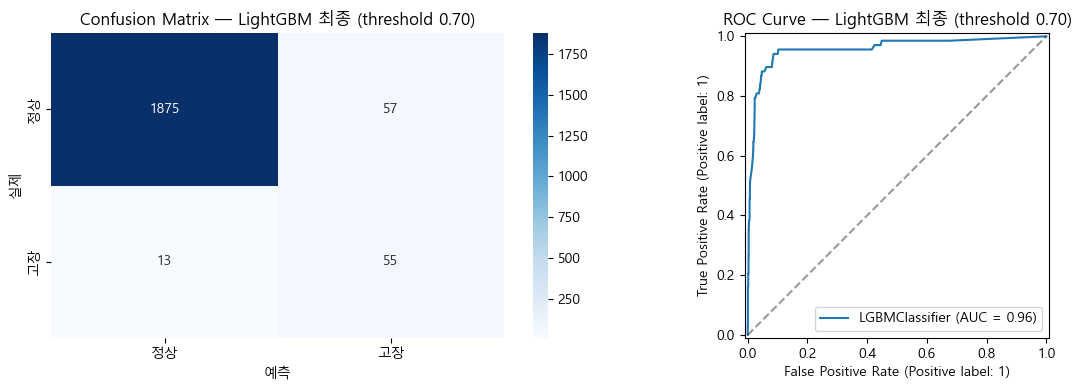


── 전체 모델 최종 비교 ──
              Model  Threshold  Recall  ROC-AUC  F1-score
Logistic Regression       0.50  0.7647   0.8271    0.1675
      Random Forest       0.20  0.7500   0.9410    0.6846
            XGBoost       0.35  0.8382   0.9700    0.4402
    LightGBM (튜닝 전)       0.50  0.8088   0.9680    0.5164
      LightGBM (최종)       0.70  0.8088   0.9585    0.6111


In [14]:
# ── 최종 모델 성능 확인 (threshold 0.70) ──────────────────────
y_pred_final  = (y_proba_best >= 0.70).astype(int)

print(f'Recall  : {recall_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_final):.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '고장'], yticklabels=['정상', '고장'])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix — LightGBM 최종 (threshold 0.70)')

# ROC 커브
RocCurveDisplay.from_estimator(best_lgbm, X_test_rf, y_test, ax=axes[1])
axes[1].set_title('ROC Curve — LightGBM 최종 (threshold 0.70)')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── 전체 모델 최종 비교표 ─────────────────────────────────────
final_summary = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM (튜닝 전)', 'LightGBM (최종)'],
    'Threshold': [0.50, 0.20, 0.35, 0.50, 0.70],
    'Recall'   : [0.7647, 0.7500, 0.8382, 0.8088, 0.8088],
    'ROC-AUC'  : [0.8271, 0.9410, 0.9700, 0.9680, 0.9585],
    'F1-score' : [0.1675, 0.6846, 0.4402, 0.5164, 0.6111],
})
print('\n── 전체 모델 최종 비교 ──')
print(final_summary.to_string(index=False))

### 교차검증 
**이 코드에서 보고 싶은 두 가지**
```
평균값  → 모델 전체 성능이 얼마나 되는지
표준편차 → 폴드마다 성능이 얼마나 들쑥날쑥한지
```

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score, f1_score

# ── threshold 0.70 반영한 5-Fold CV ──────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

THRESHOLD = 0.70
fold_results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_rf, y), 1):
    X_tr, X_val = X_rf.iloc[train_idx], X_rf.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 매 폴드마다 학습
    best_lgbm.fit(X_tr, y_tr)

    # threshold 0.70 적용
    y_proba_val = best_lgbm.predict_proba(X_val)[:, 1]
    y_pred_val  = (y_proba_val >= THRESHOLD).astype(int)

    fold_results.append({
        'Fold'   : fold,
        'Recall' : recall_score(y_val, y_pred_val),
        'ROC-AUC': roc_auc_score(y_val, y_proba_val),
        'F1'     : f1_score(y_val, y_pred_val),
    })

result_cv_df = pd.DataFrame(fold_results)
print(f'── 5-Fold CV 결과 (threshold={THRESHOLD}) ──')
print(result_cv_df.round(4).to_string(index=False))
print(f"\nRecall  : {result_cv_df['Recall'].mean():.4f} ± {result_cv_df['Recall'].std():.4f}")
print(f"ROC-AUC : {result_cv_df['ROC-AUC'].mean():.4f} ± {result_cv_df['ROC-AUC'].std():.4f}")
print(f"F1      : {result_cv_df['F1'].mean():.4f} ± {result_cv_df['F1'].std():.4f}")


── 5-Fold CV 결과 (threshold=0.7) ──
 Fold  Recall  ROC-AUC     F1
    1  0.8507   0.9753 0.5846
    2  0.8529   0.9770 0.5800
    3  0.8235   0.9706 0.5864
    4  0.8824   0.9712 0.6349
    5  0.8382   0.9733 0.6369

Recall  : 0.8496 ± 0.0218
ROC-AUC : 0.9735 ± 0.0027
F1      : 0.6046 ± 0.0287


In [16]:
import joblib

# ── 모델 저장 ─────────────────────────────────────────────────
joblib.dump(best_lgbm, 'lgbm_final.pkl')
print('모델 저장 완료 → lgbm_final.pkl')

# 나중에 불러올 때
# model = joblib.load('lgbm_final.pkl')

모델 저장 완료 → lgbm_final.pkl


# 고장 유형별 분석 

── 고장 유형별 발생 건수 ──
Type  Count                     Name
 RNF     19           Random Failure
 TWF     46        Tool Wear Failure
 PWF     95            Power Failure
 OSF     98       Overstrain Failure
 HDF    115 Heat Dissipation Failure


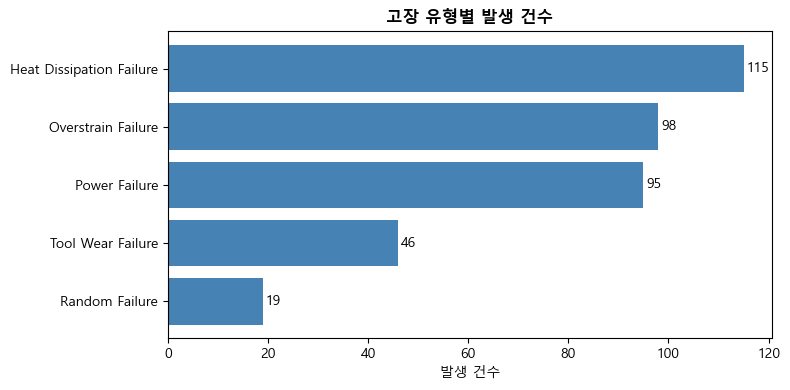


── 고장 유형별 주요 센서값 평균 ──

[ Tool Wear Failure ]
                          고장시 평균   정상시 평균       차이
Air temperature [K]       300.30   300.00     0.29
Process temperature [K]   310.17   310.00     0.16
Rotational speed [rpm]   1566.17  1538.65    27.52
Torque [Nm]                37.84    40.00    -2.16
Tool_wear_min             216.37   107.45   108.92
Temp_diff                   9.87    10.00    -0.13
Power                    6019.33  6280.95  -261.62
Torque_Wear              8188.77  4296.76  3892.01

[ Heat Dissipation Failure ]
                          고장시 평균   정상시 평균       차이
Air temperature [K]       302.56   299.98     2.59
Process temperature [K]   310.79   310.00     0.79
Rotational speed [rpm]   1337.26  1541.12  -203.86
Torque [Nm]                53.17    39.83    13.33
Tool_wear_min             107.19   107.96    -0.77
Temp_diff                   8.23    10.02    -1.79
Power                    7433.17  6266.33  1166.84
Torque_Wear              5702.38  4298.52  1403.86

[ Po

In [17]:
# ── 고장 유형별 분석 ──────────────────────────────────────────
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

# ── 1. 고장 유형별 발생 건수 ──────────────────────────────────
failure_counts = df[failure_cols].sum().reset_index()
failure_counts.columns = ['Type', 'Count']
failure_counts['Name'] = failure_counts['Type'].map(failure_names)
failure_counts = failure_counts.sort_values('Count', ascending=True)

print('── 고장 유형별 발생 건수 ──')
print(failure_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(failure_counts['Name'], failure_counts['Count'], color='steelblue')
ax.set_xlabel('발생 건수')
ax.set_title('고장 유형별 발생 건수', fontweight='bold')
for i, v in enumerate(failure_counts['Count']):
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

# ── 2. 고장 유형별 센서값 평균 비교 ──────────────────────────
# Tool wear [min] → Tool_wear_min 으로 수정
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool_wear_min',
               'Temp_diff', 'Power', 'Torque_Wear']

print('\n── 고장 유형별 주요 센서값 평균 ──')
for col in failure_cols:
    failed = df[df[col] == 1][sensor_cols].mean()
    normal = df[df[col] == 0][sensor_cols].mean()
    diff   = failed - normal
    print(f'\n[ {failure_names[col]} ]')
    print(pd.DataFrame({
        '고장시 평균': failed,
        '정상시 평균': normal,
        '차이'      : diff
    }).round(2))

# 📊 고장 유형 및 주요 특징 정리

## 1. 고장 유형별 발생 빈도
- HDF (열 방출 실패): 115건 ← 가장 많음  
- OSF (과부하 실패): 98건  
- PWF (전력 실패): 95건  
- TWF (공구 마모): 46건  
- RNF (랜덤 실패): 19건 ← 가장 적음  

---

## 2. TWF (공구 마모) 특징
- Tool_wear_min 차이: +108.92 ← 압도적  
- Torque_Wear 차이: +3892.01  

→ 공구 누적 사용시간: 216분 (정상 107분 대비 2배)  

→ 실무 기준:  
- Tool wear 200분 이상 → 교체 필요  

---

## 3. HDF (열 방출 실패) 특징
- Temp_diff 차이: -1.79 ← 온도차 감소  
- Rotational speed 차이: -203.86  

→ 온도차: 8.23K (정상 10K)  
→ rpm: 1337 (정상 1541)  

→ 실무 기준:  
- Temp_diff ≤ 9K + rpm ≤ 1380 → 위험  

---

## 4. PWF (전력 실패) 특징
- Power 차이: +981.40 ← 전력 증가  
- Rotational speed 차이: +227.35  

→ 실무 기준:  
- Power ≥ 7000 → 점검 필요  

---

## 5. OSF (과부하 실패) 특징
- Torque_Wear 차이: +7829.05 ← 압도적  
- Torque 차이: +18.57  
- Tool_wear_min 차이: +100.73  

→ 토크 58Nm + 마모 207분 → 과부하  

→ 실무 기준:  
- Torque_Wear ≥ 10000 → 위험  

---

## 6. RNF (랜덤 실패) 특징
- 모든 센서값 차이가 작음  

→ 특정 패턴 없음  
→ 예측이 가장 어려운 유형  

---

# ✅ 한 줄 정리
→ 대부분 고장은 마모, 온도, 토크, 전력의 임계값 초과로 발생  
→ RNF는 규칙 없이 발생하는 예외적 고장

# SHAP 분석 

C:\Users\woain\miniconda3\envs\ml_project\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
SHAP values shape: (2000, 5)


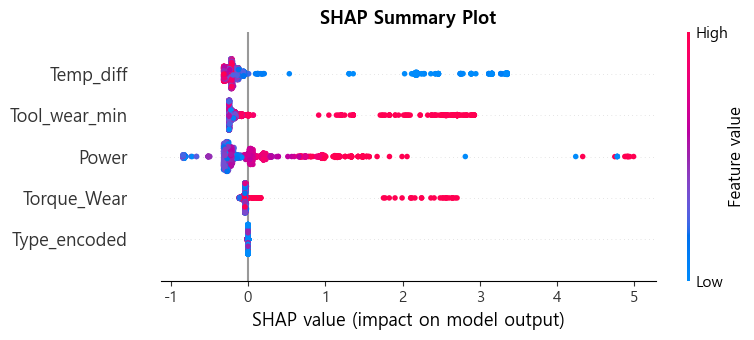

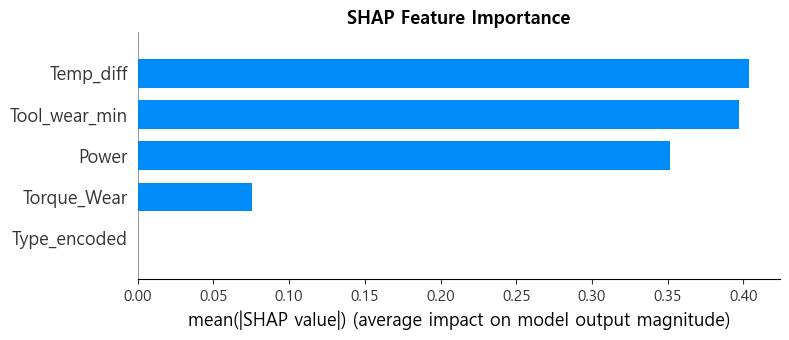

expected_value: -2.0278673614721585
type: <class 'numpy.float64'>


C:\Users\woain\miniconda3\envs\ml_project\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\woain\miniconda3\envs\ml_project\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


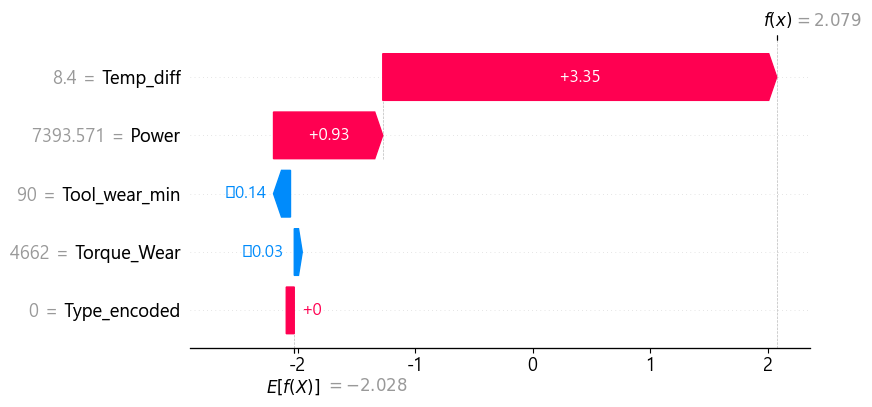

In [22]:
import shap

# ── 1. SHAP 값 계산 ───────────────────────────────────────────
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test_rf)

# 새 버전은 list로 반환 → [0]이 정상, [1]이 고장
# list 형태 확인
print(type(shap_values))
print(type(shap_values[0]))

# 고장 클래스 기준으로 선택
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # 새 버전
else:
    shap_vals = shap_values     # 구 버전

print(f'SHAP values shape: {shap_vals.shape}')

# ── 2. Summary Plot ───────────────────────────────────────────
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_test_rf,
                  feature_names=FEATURES_RF,
                  show=False)
plt.title('SHAP Summary Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Bar Plot ───────────────────────────────────────────────
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_vals, X_test_rf,
                  feature_names=FEATURES_RF,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Waterfall Plot ─────────────────────────────────────────
tp_idx = np.where((y_test.values == 1) & (y_pred_final == 1))[0][0]

# expected_value 형식 확인 후 처리
print(f'expected_value: {explainer.expected_value}')
print(f'type: {type(explainer.expected_value)}')

# list면 [1], 스칼라면 그대로 사용
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[tp_idx],
        base_values=base_val,
        data=X_test_rf.iloc[tp_idx],
        feature_names=FEATURES_RF
    )
)

# Summary Plot 해석
### 빨간색 = 피처값 높음, 파란색 = 피처값 낮음
- Temp_diff  → 값이 낮을 때(파란) SHAP 양수  ← 온도차 낮으면 고장 확률 올라감
- Tool_wear  → 값이 높을 때(빨간) SHAP 양수  ← 마모 높으면 고장 확률 올라감
- Power      → 값이 높을 때(빨간) SHAP 양수  ← 전력 높으면 고장 확률 올라감
- Torque_Wear→ 값이 높을 때(빨간) SHAP 양수  ← 과부하 높으면 고장 확률 올라감
- Type_encoded → 영향 거의 없음
# Feature Importance (SHAP 기준)

- 1위  Temp_diff    0.38  ← 가장 중요
- 2위  Tool_wear    0.33
- 3위  Power        0.30
- 4위  Torque_Wear  0.05
- 5위  Type_encoded 0.00

-> 피처 중요도에서 Power가 1위였는데 SHAP에서는 Temp_diff가 1위로 바뀜
평균적인 중요도와 실제 영향력이 다를 수 있다는 걸 보여줌

# Waterfall Plot 해석 (고장 샘플 1개)
- 기본값 E[f(x)] = -2.028 (고장 확률 낮은 상태)

- Temp_diff = 8.4   → +3.35 ← 온도차가 낮아서 고장 확률 크게 올림
- Power = 7393      → +0.93 ← 전력이 높아서 고장 확률 올림
- Tool_wear = 90    → +0.14 ← 소폭 올림
- Torque_Wear = 4662→ +0.03 ← 거의 영향 없음
- Type_encoded = 0  → +0.00 ← 영향 없음

최종 f(x) = 2.079 → 고장으로 예측


# 실무기준 최종정리
- 📌 Temp_diff  ≤ 9K           → HDF 위험 (가장 중요!)
- 📌 Tool_wear  ≥ 200min       → TWF 위험
- 📌 Power      ≥ 7000W        → PWF 위험
- 📌 Torque_Wear ≥ 10000       → OSF 위험